[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KalininGroup/camm_hackathon/blob/k4my4r/docs/day_5_11212025/2025_Ferrosim_CAMM_hackaton.ipynb)


# **FerroSim: Kinetic Lattice Ferroelectric Model**

**Author: Rama Vasudevan**

This simulator evolves a ferroelectric polarization field using a time-dependent Ginzburg–Landau (TDGL) model on a 2D lattice. Each site carries a polarization order parameter:

- **Uniaxial:** scalar $p_{ij}$
- **Squareelectric:** two uncoupled components $(p_{x,ij},p_{y,ij})$
- **Tetragonal / Rhombohedral:** coupled vector $(p_{x,ij},p_{y,ij})$

The total free energy is:
$$
F = F_{\text{Landau}} + F_{\text{coupl}} + F_{\text{field}}
$$

### **1. Landau Free Energy (local double-well / multi-well potential)**

- **Uniaxial / Squareelectric:**
  $$
  F_L = \frac{\alpha_1}{2}p^2 + \frac{\alpha_2}{4}p^4
  $$
- **Tetragonal / Rhombohedral:**
  $$
  F_L = \alpha_1 (p_x^2+p_y^2)
       + \alpha_2 (p_x^4+p_y^4)
       + \alpha_3 p_x^2 p_y^2
  $$

### **2. Couping Energy**

$$
F_{\text{coupl}} = K \sum_{k,l} (p_{ij} - p_{i+k,j+l})^2
$$


### **3. Electric Field Terms**

Local field:
$$
E_{\text{loc}} = E_{\text{ext}} + E_{\text{dep}} + E_d(i,j)
$$

Depolarization field:
$$
E_{\text{dep}} = -\alpha_{\text{dep}} \langle P \rangle
\qquad
\langle P \rangle = \frac{1}{N^2}\sum_{ij} p_{ij}
$$

External field $E_{\text{ext}}(t)$ can be an arbitrary waveform.

Defect field $E_d(i,j)$ introduces random-field.

### **4. TDGL Dynamics**

Evolution follows:
$$
\frac{dp_{ij}}{dt} = -\gamma \frac{\partial F}{\partial p_{ij}}
$$

Updated explicitly:
$$
p_{ij}(t+\Delta t) = p_{ij}(t) + \Delta t\,\frac{dp_{ij}}{dt}
$$

$\gamma$ is the mobility (domain-wall damping).  
$\Delta t$ is the numerical time step.

### **5. Model Parameters**

- **Landau coefficients:** $\alpha_1, \alpha_2, \alpha_3$
- **Coupling:** $K$
- **Depolarizing coef.:** $\alpha_{\text{dep}}$
- **External field:** $E_{\text{ext}}(t)$
- **Defect field:** $E_d(i,j)$
- **Mobility:** $\gamma$
- **Time step:** $\Delta t$

### **Modes Summary**

- **Uniaxial:** scalar double-well potential.
- **Squareelectric:** two independent double wells in $x$ and $y$.
- **Tetragonal:** coupled components; minima along axes.
- **Rhombohedral:** coupled components; minima along diagonal directions.

This toy model captures ferroelectric switching, domain formation, domain wall motion, defect pinning, and polarization dynamics under applied fields.


**Default coef.** **$\alpha_1$ $\alpha_2$ $\alpha_3$**

*Uniaxial:* -1.85,	1.25, N/A

*Squareelectric:* -1.85,	1.25, N/A

*Tetragonal:* -1.6	12.2	40.0

*Rhombohedral:* -10.6	10.2	-10.0

**NOTE: The coefficients for the rhomohedral case don't appear to be very good. Need to adjust them.**





---






**Github**: https://github.com/ramav87/FerroSim/tree/rama-dev (branch: rama-dev)

In [2]:
!pip install -e git+https://github.com/ramav87/FerroSim.git@rama-dev#egg=FerroSim

Obtaining FerroSim from git+https://github.com/ramav87/FerroSim.git@rama-dev#egg=FerroSim
  Cloning https://github.com/ramav87/FerroSim.git (to revision rama-dev) to ./src/ferrosim
  Running command git clone --filter=blob:none --quiet https://github.com/ramav87/FerroSim.git /content/src/ferrosim
  Running command git checkout -b rama-dev --track origin/rama-dev
  Switched to a new branch 'rama-dev'
  Branch 'rama-dev' set up to track remote branch 'rama-dev' from 'origin'.
  Resolved https://github.com/ramav87/FerroSim.git to commit 83b79be078001e93d4d10fcab403ba2f8d688a27
  Preparing metadata (setup.py) ... done
  Running setup.py develop for FerroSim




> **Session must be restarted after ferrosim lib uploading**



In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib import gridspec

import h5py
import math

from typing import Dict
from itertools import product

from ferrosim import Ferro2DSim

## Uniaxial switching

---Performing simulation---


100%|██████████| 498/498 [00:04<00:00, 104.40it/s]


---Performing simulation---


100%|██████████| 498/498 [00:03<00:00, 134.61it/s]


---Performing simulation---


100%|██████████| 498/498 [00:02<00:00, 193.65it/s]


---Performing simulation---


100%|██████████| 498/498 [00:03<00:00, 145.42it/s]


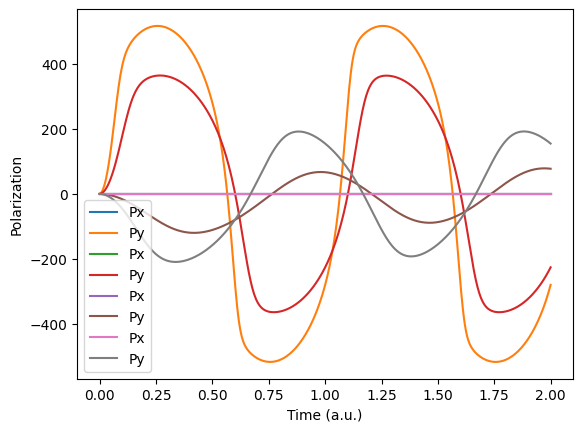

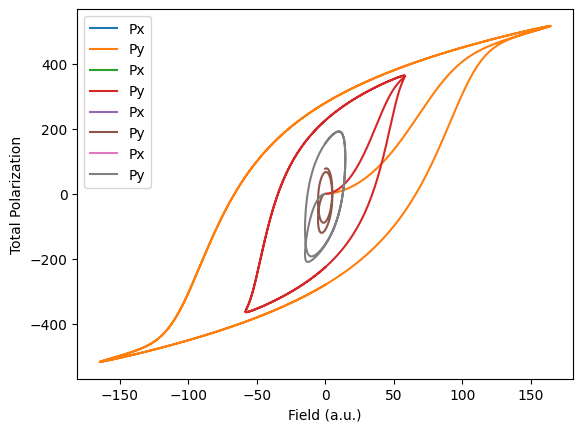

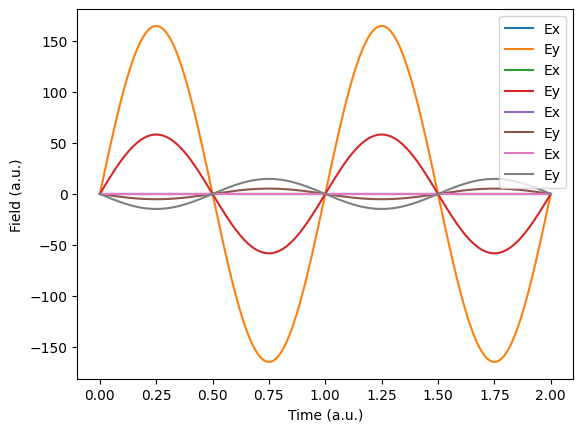

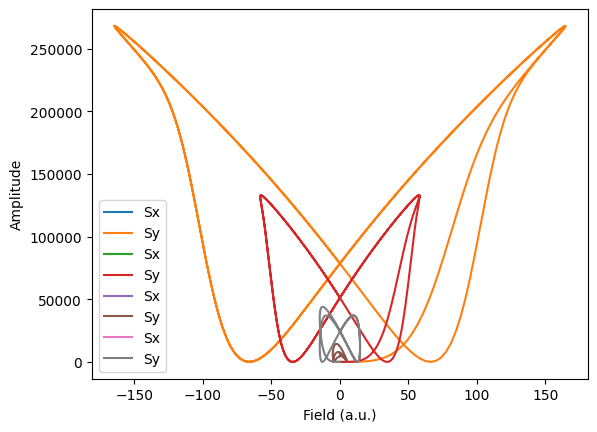

In [2]:
Pmats = []
for temp in [300, 350, 410, 420]:
  time_vec = np.linspace(0,2,500)

  #Let's now make a somewhat complicated electric field
  Evec_x = 0*np.ones(len(time_vec))
  Evec_y = 190*np.sin(2*np.pi*time_vec)
  applied_field = np.vstack((Evec_x, Evec_y)).T

  landau_parms = {'alpha1': 1.85/100 , 'alpha2':1.25 } #alpha1 is technically the temperature independent term, it gets multiplied by T diff.

  init_pmat = np.random.uniform(low = -0.2, high = 0.2, size = (10,10))*1.0E-6
  init_pmat_full = np.zeros(shape=(10,10,2))
  init_pmat_full[:,:,1] = init_pmat


  sim = Ferro2DSim(mode = 'uniaxial',
                   k = 1.0,
                   temp = temp,
                   time_vec = time_vec,
                   appliedE = applied_field,
                   initial_p = init_pmat_full,
                   landau_parms = landau_parms,
                   )
  sim.runSim()

  sim.plot_summary()
  #sim.plot_quiver()
  Pmats.append(sim.getPmat())
  del sim

(array([-600., -400., -200.,    0.,  200.,  400.,  600.]),
 [Text(0, -600.0, '−600'),
  Text(0, -400.0, '−400'),
  Text(0, -200.0, '−200'),
  Text(0, 0.0, '0'),
  Text(0, 200.0, '200'),
  Text(0, 400.0, '400'),
  Text(0, 600.0, '600')])

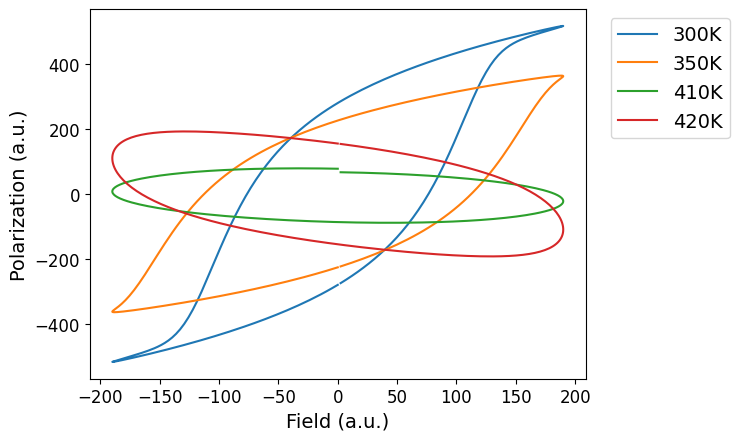

In [3]:
plt.figure()
labels = ['300K', '350K', '410K', '420K']
for ind in range(4):
  fe_loop = Pmats[ind][1,:,:,:].sum(axis=((-1,-2)))
  plt.plot(applied_field[250:,1], fe_loop[250:], label = labels[ind])
plt.legend(loc = [1.05, 0.65], fontsize = 14)

plt.xlabel('Field (a.u.)', fontsize = 14)
plt.ylabel('Polarization (a.u.)', fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

## Custom field: tetragonal

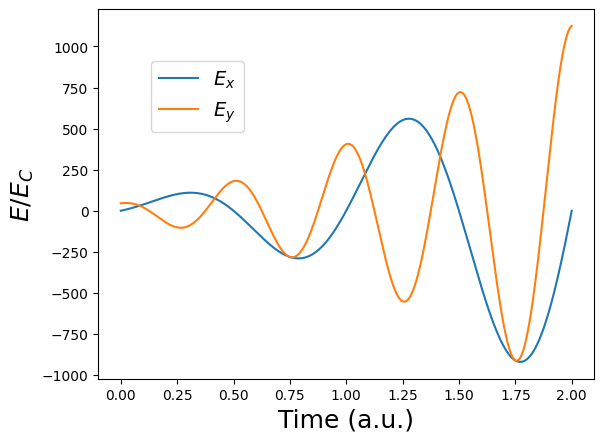

In [4]:
time_vec = np.linspace(0,2,500)

#Let's now make a somewhat complicated electric field
Evec_x = 180*((time_vec+0.5)**2)*np.sin(2*np.pi*time_vec)
Evec_y = 180*((time_vec+0.5)**2)*np.cos(4*np.pi*time_vec)

applied_field = np.vstack((Evec_x, Evec_y)).T

#Let's plot this to see what it looks like
fig, axes = plt.subplots()
axes.plot(time_vec, applied_field[:,0], label ='$E_x$')
axes.plot(time_vec, applied_field[:,1], label ='$E_y$')
axes.set_xlabel('Time (a.u.)', fontsize = 18)
axes.set_ylabel('$E/E_C$', fontsize = 18)
fig.legend(loc = [0.25, 0.70], fontsize = 14)

---Performing simulation---


100%|██████████| 498/498 [00:15<00:00, 32.29it/s]


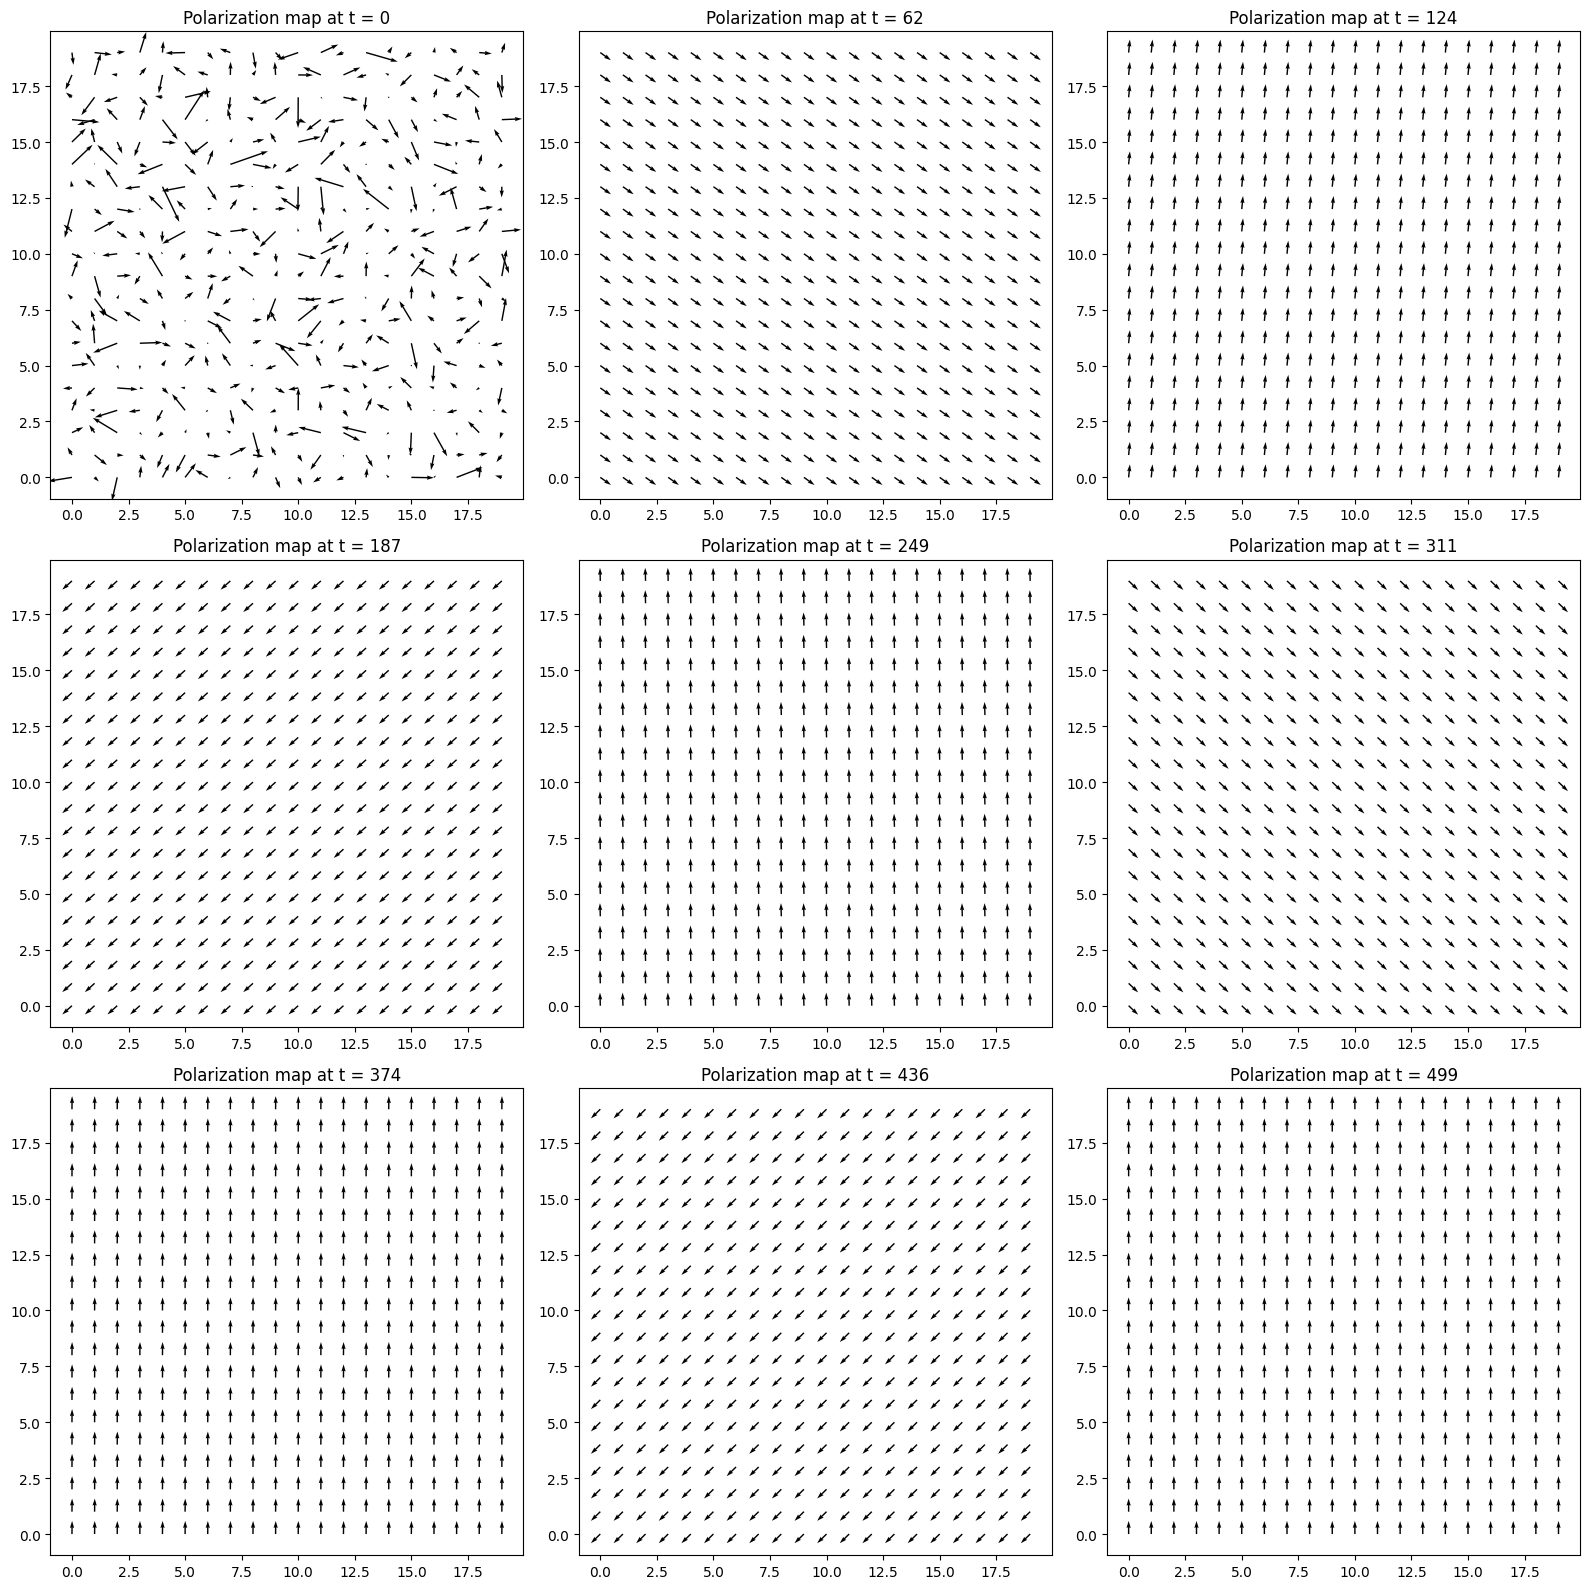

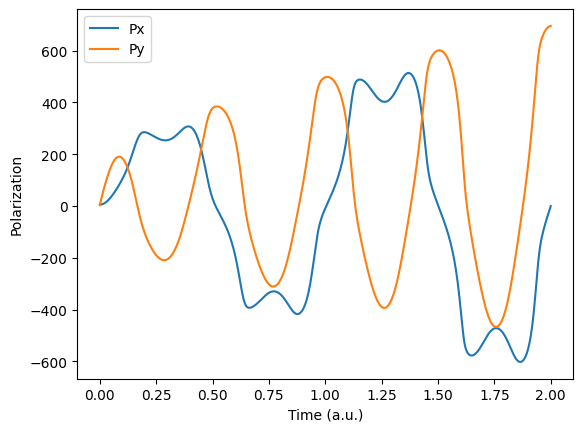

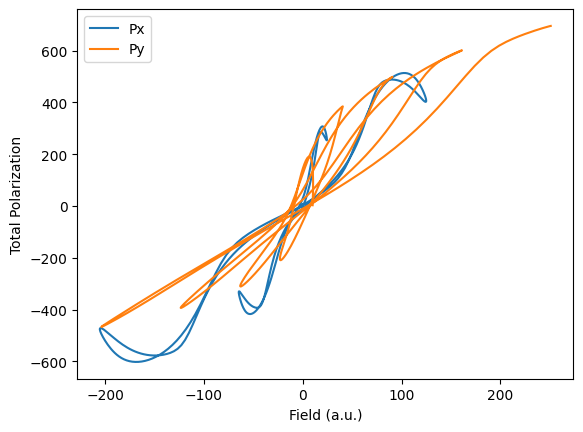

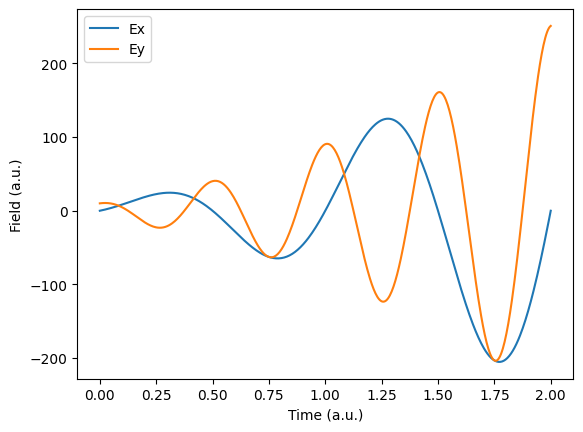

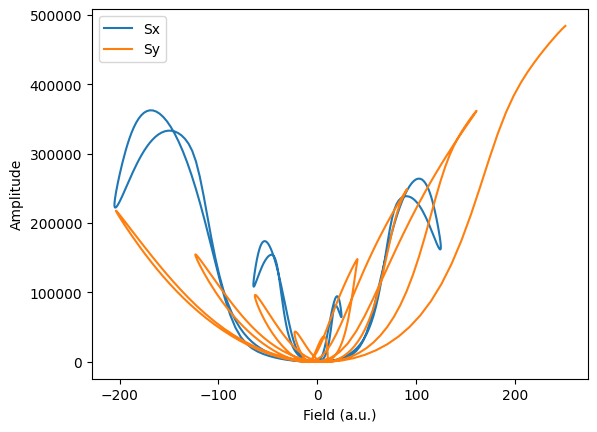

In [5]:
sim = Ferro2DSim(n=20, time_vec = time_vec, appliedE= applied_field,
                 mode = 'tetragonal', init = 'random')
sim.runSim()
sim.plot_quiver()
sim.plot_summary()

## Adding Custom Defects

We can also add defects to the simulation easily.

### Random Field Effects
Defects can interact with the lattice through field effects (no elastic considerations in this model whatsoever). The simulation expects defects to be entered in as a list of length (n x n) with each element being a tuple $(RF_x, RF_y)$. The units of the $RF_x$ and $RF_y$ are, as with the applied field, multiples of the nominal coercive field (set by the simulations alpha and beta values in the Landau expansion - that can also be changed if you so wish!).

### Random Bond Effects
We can also add defects that produce random-bond disorder: in this case, the coupling constant k is no longer uniform, but spatially dependent. So, k should now be provided as a list of size (n x n). The Default is a list of length (n x n) with all elements set to 1.0.

### Screening effects
Finally, we note that depolarization effects are considered in the model as a uniform constant multipled by the total polarization. However, we can alter this by assuming some screening (e.g., from migration of internal charges, or band bending etc.). The simulation then expects a list of length (n x n) with each element equal to the factor that multiples the total polarization. The Default is set to 0.0 at all sites.

In [6]:
n = 20 #lattice size
time_vec = np.linspace(0,4,500)

defect_list = []
for row in range(n):
    for col in range(n):
        Efx = 0.01
        Efy = 0.01
        #We place defects every fifth row and 2nd column
        if row%5==0 and col%10==0: Efy = np.random.normal(loc = 15.5, scale = 0.1)

        defect_list.append((Efx, Efy))
defect_list = np.array(defect_list)


#Let's add some random bond disorder. Here we will assume the random bond disorder
#is just a small noise term on teh existing constant value
k = [np.random.normal(loc=1.0,scale = 0.1) for ind in range(n*n)]

#Finally, let's also play with the depolarization. In this case it is going to be random.
dep_alpha = [np.random.uniform(low=0.4, high= 0.8) for ind in range(n*n)]

#Let's just have a sinusoidal field
Evec_x = 10*np.ones(len(time_vec))
Evec_y = 190*np.sin(2*np.pi*time_vec)
applied_field = np.vstack((Evec_x, Evec_y)).T

In [7]:
sim = Ferro2DSim(n=n,
                 time_vec = time_vec,
                 appliedE=applied_field,
                 defects=defect_list,
                 k=k,
                 dep_alpha = dep_alpha,
                 mode = 'tetragonal')

---Performing simulation---


100%|██████████| 498/498 [00:12<00:00, 38.43it/s]


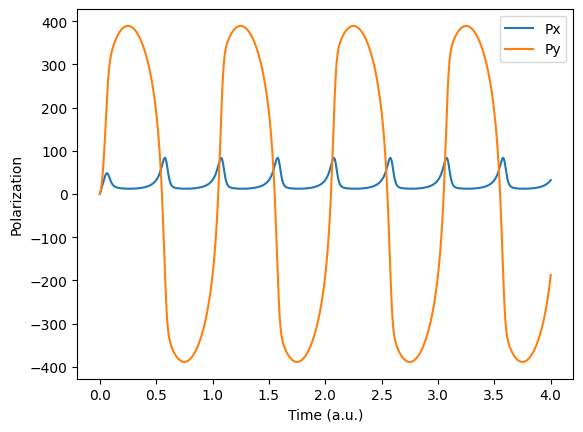

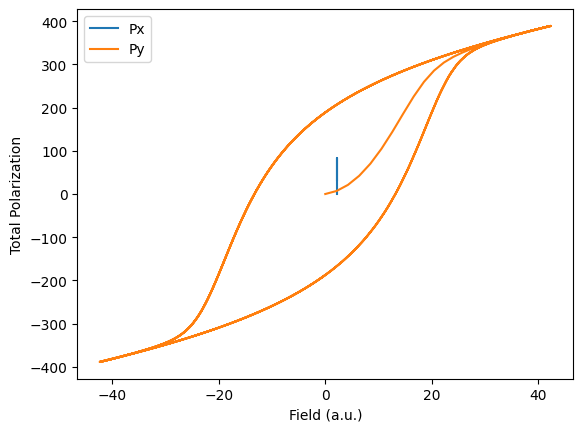

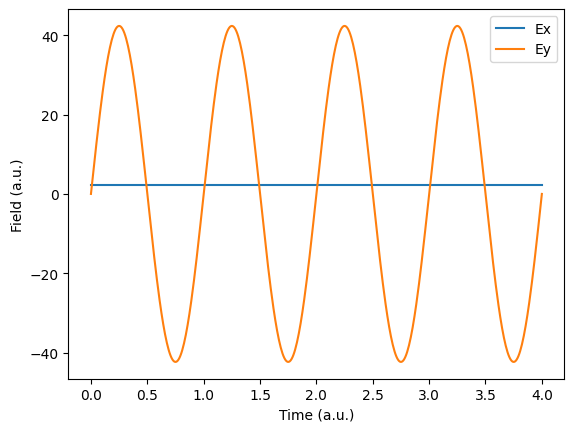

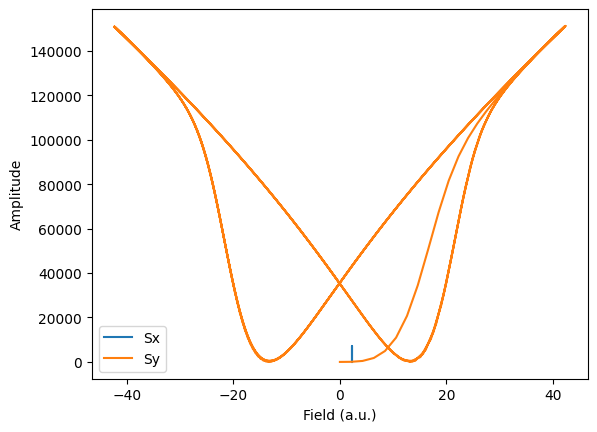

In [8]:
sim.runSim()
sim.plot_summary()

## "Domain" structures

In [9]:
def ferrosim_calc1(patch,
                  gamma = 30,
                  defect_field = (30,.01),
                  c_const = 1.1,
                  Eamp = (0, 2),
                  time_vec_length = 3000,
                  dep_alpha = 1E-9):
  #tiem vec
  time_vec = np.linspace(0,2,time_vec_length)
  flat_patch = np.array(patch.flatten())

  #defect field
  Efx, Efy = defect_field

  defect_list = np.zeros((len(flat_patch),2))#np.ones((len(flat_patch),2))*1E-6
  defect_list[flat_patch==0] = (Efx, 0)
  defect_list[flat_patch!=0] =  np.array([np.zeros(len(flat_patch[flat_patch!=0])), -flat_patch[flat_patch!=0]*Efy]).T

  #coupling constant
  k = np.zeros(len(flat_patch))
  k[flat_patch!=0] = c_const

  #applied field
  Evec_x = Eamp[0]*np.ones(len(time_vec))
  Evec_y = Eamp[1]*np.sin(2*np.pi*time_vec)
  applied_field = np.vstack((Evec_x, Evec_y)).T

  #initial P
  init_p  = np.zeros((ws,ws,2))#np.random.uniform(low = -0.2, high = 0.2, size = (ws,ws,2))*1.0E-9

  init_p[:,:,0][patch==0] = 1
  init_p[:,:,1][patch!=0] = patch[patch!=0]*.5

  sim = Ferro2DSim(n=ws,
                  time_vec = time_vec,
                  appliedE=applied_field,
                  defects=defect_list,
                  k=k,
                  dep_alpha = dep_alpha,
                  mode = 'tetragonal',
                  gamma=gamma,
                  initial_p = init_p,)

  sim.runSim();

  return (applied_field.T, sim.results['Polarization'])


def res_pattern(k, stripe_frequency, phase, size=(12,12)):
  c_domain_pattern = c_domain(k, size=size)
  a_domain_pattern = striped_pattern(stripe_frequency, phase, size=size)
  res = (c_domain_pattern*2-1) * (~a_domain_pattern)
  return res, c_domain_pattern, a_domain_pattern

def c_domain(k, size=(12,12)):
  a_pattern = np.array([[1 if (i-k < j) else 0 for j in range(size[0])] for i in range(size[1])])
  return a_pattern.astype(bool)

def striped_pattern(stripe_frequency, phase, size=(12,12), stripe_width=2):
  pattern = np.zeros(size, dtype=int)

  for i in range(size[0]):
      for j in range(size[1]):
          if ((i + j) // stripe_width + phase) % stripe_frequency == 0:
              pattern[i, j] = 1

  return pattern.astype(bool)

def shoelace_formula(x, y):
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

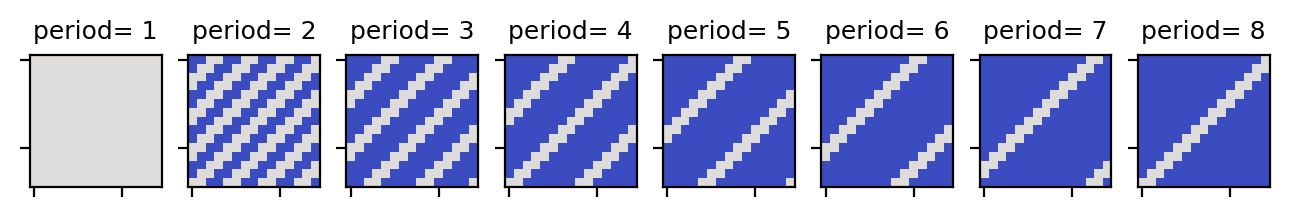

In [10]:
ws = 15

sf = np.arange(1,9)

patterns = []
for f in sf:
  patterns.append(res_pattern(-15, f, 1, size=(ws,ws)))


fig, ax = plt.subplots(1, len(patterns), figsize=(len(patterns), 1.2), dpi=200)

for i,p in enumerate(patterns):
  ax[i].imshow(p[0], vmin=-1, vmax=1, cmap='coolwarm')
  ax[i].tick_params(labelleft=False, labelbottom=False)
  ax[i].set_title(f"period= {sf[i]}", fontsize=9)

In [11]:
pol_ar = []

for i,p in enumerate(patterns):
  v, pol = ferrosim_calc1(p[0],
                  gamma = 30, #kinetic coefficient in Landau-Khalatnikov equation (~wall mobility)
                  defect_field = (30,.1),
                  c_const = 0, #coupling constant
                  Eamp = (0, 2), #amplitude of the applied voltage
                  time_vec_length = 2000, #number of the time steps, we always apply 2 sin period
                  dep_alpha = .3 #depolarization constant
                          )
  pol_ar.append(pol)

pol_ar = np.array(pol_ar) #polarization hysteresis loops

---Performing simulation---


100%|██████████| 1998/1998 [00:31<00:00, 64.32it/s]


---Performing simulation---


100%|██████████| 1998/1998 [00:29<00:00, 67.45it/s]


---Performing simulation---


...

100%|██████████| 1998/1998 [00:28<00:00, 70.12it/s]


---Performing simulation---


100%|██████████| 1998/1998 [00:30<00:00, 66.23it/s]


---Performing simulation---


100%|██████████| 1998/1998 [00:28<00:00, 69.11it/s]


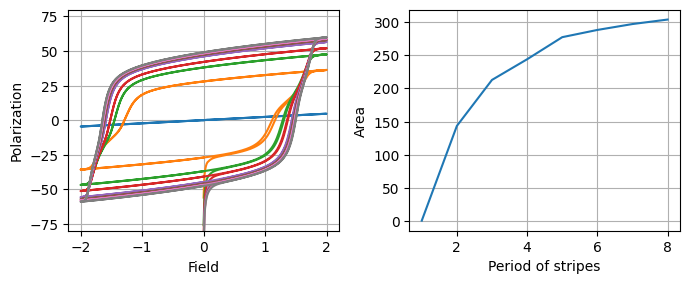

In [12]:
loop_area = np.array([])
fig, ax = plt.subplots(1,2, figsize=(7,3))

for pp in pol_ar:
  loop_area = np.append(loop_area, float(shoelace_formula(v[1,-1000:], pp[1, -1000:]))) #
  ax[0].plot(v[1], pp[1])

ax[0].grid()
ax[0].set_ylabel("Polarization")
ax[0].set_xlabel("Field")
ax[0].set_ylim(-80,80)

ax[1].plot(sf, loop_area)
ax[1].grid()
ax[1].set_ylabel('Area')
ax[1].set_xlabel('Period of stripes')

plt.tight_layout()